In [1]:
records = [
    "04015",
    "04043",
    "04048",
    "04126",
    "04936",
    "05091",
    "05121",
    "05261"
]

for rec in records:
    print(rec)

04015
04043
04048
04126
04936
05091
05121
05261


In [3]:
import wfdb
import numpy as np
from tqdm import tqdm

In [4]:
records = [
    "04015",
    "04043",
    "04048",
    "04126",
    "04936",
    "05091",
    "05121",
    "05261"
]

print("Total Records:", len(records))

Total Records: 8


In [5]:
base_path = r"C:\Users\hrkap\OneDrive\Desktop\VitaTwin-AI project\datasets\raw\afdb"

In [6]:
all_segments = []
all_labels = []

window_size = 1250

In [7]:
for record_name in tqdm(records):

    print(f"\nProcessing {record_name}")

    record = wfdb.rdrecord(
        f"{base_path}\\{record_name}"
    )

    ann = wfdb.rdann(
        f"{base_path}\\{record_name}",
        "atr"
    )

    signal = record.p_signal[:,0]

    rhythm_intervals = []

    for i in range(len(ann.sample)-1):

        start = ann.sample[i]
        end = ann.sample[i+1]

        rhythm = ann.aux_note[i]

        rhythm_intervals.append(
            (start, end, rhythm)
        )

    for seg_idx in range(
        0,
        len(signal)-window_size,
        window_size
    ):

        segment = signal[
            seg_idx:seg_idx+window_size
        ]

        label = 0

        for start, end, rhythm in rhythm_intervals:

            if start <= seg_idx < end:

                if "AFIB" in rhythm:
                    label = 1

                break

        all_segments.append(segment)
        all_labels.append(label)

  0%|          | 0/8 [00:00<?, ?it/s]


Processing 04015


 12%|█▎        | 1/8 [00:00<00:04,  1.64it/s]


Processing 04043


 25%|██▌       | 2/8 [00:01<00:04,  1.45it/s]

...

 75%|███████▌  | 6/8 [00:03<00:01,  1.58it/s]


Processing 05121


 88%|████████▊ | 7/8 [00:04<00:00,  1.53it/s]


Processing 05261


100%|██████████| 8/8 [00:05<00:00,  1.55it/s]


In [8]:
X = np.array(all_segments)
y = np.array(all_labels)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (58912, 1250)
y Shape: (58912,)


In [9]:
print("Normal:", np.sum(y == 0))
print("AFIB:", np.sum(y == 1))

Normal: 46866
AFIB: 12046


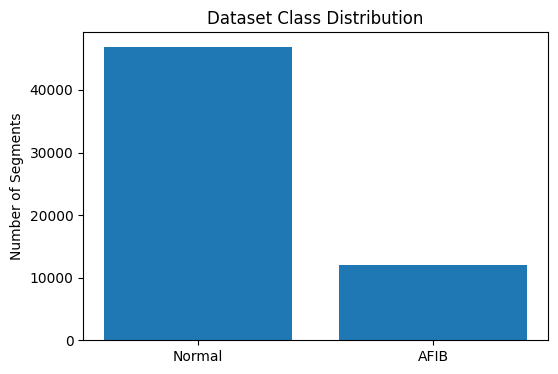

In [10]:
import matplotlib.pyplot as plt

normal_count = np.sum(y == 0)
afib_count = np.sum(y == 1)

plt.figure(figsize=(6,4))

plt.bar(
    ["Normal","AFIB"],
    [normal_count, afib_count]
)

plt.title("Dataset Class Distribution")
plt.ylabel("Number of Segments")

plt.show()

In [11]:
np.save("X.npy", X)
np.save("y.npy", y)

print("Dataset Saved Successfully")

Dataset Saved Successfully
